# 个人作业2：桌游复杂度与玩家评分的量化关系（深度建模）
## —— PCA降维 · K-Means聚类 · 时间序列分析
### 大数据处理技术课程 — 2025-2026第二学期
**在作业1基础上深化**


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from scipy import stats
from scipy.signal import argrelextrema
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

print("环境就绪 — PCA + K-Means + 时间序列")


环境就绪 — PCA + K-Means + 时间序列


In [2]:
# 加载并清洗数据（复用作业1的数据处理流程）
df = pd.read_csv('data/bgg_board_games.csv')
rating_col = 'average_rating'

# 数据清洗流程（与作业1相同）
df = df[df['users_rated'] >= 30].copy()
df = df[df['year_published'] > 0].copy()
df = df[df['year_published'] <= 2026].copy()
df = df[df['playing_time'] > 0].copy()
df = df[(df[rating_col] >= 1) & (df[rating_col] <= 10)].copy()

for col in df.select_dtypes(include=[np.number]).columns:
    df[col].fillna(df[col].median(), inplace=True)
for col in df.select_dtypes(include=['object']).columns:
    df[col].fillna('Unknown', inplace=True)

# 衍生特征
df['log_users_rated'] = np.log1p(df['users_rated'])
df['mechanics_count'] = df['mechanic'].fillna('').str.split(',').apply(
    lambda x: len([i for i in x if i.strip() != ''])
)
time_bins = [0, 30, 60, 120, 99999]
time_labels = ['<30 min', '30-60 min', '60-120 min', '>120 min']
df['time_bin'] = pd.cut(df['playing_time'], bins=time_bins, labels=time_labels)

print(f"数据加载完成: {len(df):,} 款游戏, {df.shape[1]} 列")
print(f"年份范围: {df['year_published'].min():.0f}-{df['year_published'].max():.0f}")
print(f"准备进行深度建模。")


数据加载完成: 10,182 款游戏, 25 列
年份范围: 1950-2016
准备进行深度建模。


In [3]:
# 机制独热编码
# 将100+个机制标签转换为二进制特征矩阵

# 获取最常见机制（出现在>=100款游戏中）
all_mechanics = df['mechanic'].dropna().str.split(',').explode().str.strip()
mech_freq = all_mechanics.value_counts()
common_mechanics = mech_freq[mech_freq >= 100].index.tolist()
print(f"常见机制（>=100款游戏）: {len(common_mechanics)}")

# 对前80个机制进行独热编码（控制维度）
top_n = 80
selected_mechanics = common_mechanics[:top_n]
for mech in selected_mechanics:
    col_name = f'mech__{mech.replace(" ", "_").replace("/", "_")}'
    df[col_name] = df['mechanic'].fillna('').str.contains(mech, regex=False).astype(int)

# 同时对最常见类别进行编码
all_categories = df['category'].dropna().str.split(',').explode().str.strip()
cat_freq = all_categories.value_counts()
common_categories = cat_freq[cat_freq >= 200].index.tolist()[:20]
for cat in common_categories:
    col_name = f'cat__{cat.replace(" ", "_").replace("/", "_")}'
    df[col_name] = df['category'].fillna('').str.contains(cat, regex=False).astype(int)

mech_cols = [c for c in df.columns if c.startswith('mech__')]
cat_cols = [c for c in df.columns if c.startswith('cat__')]
print(f"机制特征: {len(mech_cols)}, 类别特征: {len(cat_cols)}")
print(f"总计独热编码特征: {len(mech_cols) + len(cat_cols)}")


常见机制（>=100款游戏）: 45


机制特征: 45, 类别特征: 20
总计独热编码特征: 65


## 模块A：PCA降维 — 桌游机制空间可视化


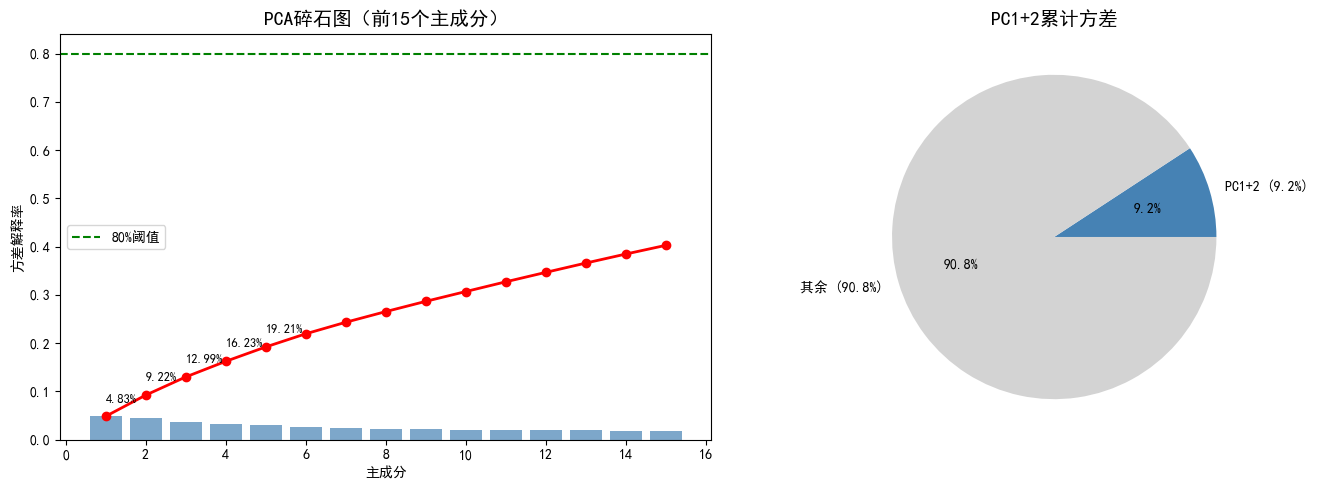

PCA碎石图已保存至 output/pca_scree.png

PCA结果:
  PC1方差: 4.83%
  PC2方差: 4.39%
  PC1+2累计: 9.22%
  PC1+2+3累计: 12.99%
  达到80%所需主成分数: 43


In [4]:
# PCA降维
# 将80维机制空间降至2-3个可解释的主成分

feature_cols = mech_cols + cat_cols
X = df[feature_cols].fillna(0).values

# 标准化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# 方差解释
explained_var = pca.explained_variance_ratio_
cumsum_var = np.cumsum(explained_var)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 碎石图
axes[0].bar(range(1, 16), explained_var[:15], alpha=0.7, color='steelblue')
axes[0].plot(range(1, 16), cumsum_var[:15], 'r-o', linewidth=2, markersize=6)
axes[0].set_xlabel('主成分')
axes[0].set_ylabel('方差解释率')
axes[0].set_title('PCA碎石图（前15个主成分）', fontsize=14, fontweight='bold')
axes[0].axhline(y=0.8, color='green', linestyle='--', label='80%阈值')
for i in range(5):
    axes[0].annotate(f'{cumsum_var[i]:.2%}', (i+1, cumsum_var[i]),
                     textcoords="offset points", xytext=(0, 10), fontsize=9)
axes[0].legend()

# PC1+2 share
axes[1].pie([explained_var[:2].sum(), 1 - explained_var[:2].sum()],
            labels=[f'PC1+2 ({explained_var[:2].sum():.1%})', f'其余 ({1-explained_var[:2].sum():.1%})'],
            autopct='%1.1f%%', colors=['steelblue', 'lightgray'])
axes[1].set_title('PC1+2累计方差', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('output/pca_scree.png', dpi=150, bbox_inches='tight')
plt.show()
print("PCA碎石图已保存至 output/pca_scree.png")

print(f"\nPCA结果:")
print(f"  PC1方差: {explained_var[0]:.2%}")
print(f"  PC2方差: {explained_var[1]:.2%}")
print(f"  PC1+2累计: {cumsum_var[1]:.2%}")
print(f"  PC1+2+3累计: {cumsum_var[2]:.2%}")
print(f"  达到80%所需主成分数: {np.argmax(cumsum_var >= 0.8) + 1}")


In [5]:
# PCA载荷分析
# 解释每个主成分代表的含义

pc1, pc2 = X_pca[:, 0], X_pca[:, 1]

loadings = pd.DataFrame(
    pca.components_[:2].T,
    index=feature_cols,
    columns=['PC1', 'PC2']
)

# Top contributing mechanics to PC1
print("-" * 50)
print("PC1 - 贡献最大的机制（定义该维度的含义）")
print("-" * 50)
print("\nPC1正载荷（最强正向）:")
for idx, row in loadings.nlargest(8, 'PC1').iterrows():
    name = idx.replace('mech__', '').replace('_', ' ').replace('cat__', '[Cat] ')
    print(f"  {name}: +{row['PC1']:.3f}")

print("\nPC1负载荷（最强负向）:")
for idx, row in loadings.nsmallest(8, 'PC1').iterrows():
    name = idx.replace('mech__', '').replace('_', ' ').replace('cat__', '[Cat] ')
    print(f"  {name}: {row['PC1']:.3f}")

print(f"\nPC1解读: ", end='')
# Auto-interpret based on top loadings
top_pos_pc1 = loadings.nlargest(3, 'PC1').index.tolist()
if any('Card' in m for m in top_pos_pc1):
    print("PC1 = 策略向 vs 休闲向轴（卡牌/策略 vs 派对/家庭）")
elif any('Dice' in m for m in top_pos_pc1):
    print("PC1 = 运气 vs 策略轴（骰子/随机 vs 确定性）")
else:
    print("PC1 = 复杂策略 vs 简单派对游戏")

print("\nPC2 - 贡献最大的机制:")
print("PC2正载荷（最强正向）:")
for idx, row in loadings.nlargest(5, 'PC2').iterrows():
    name = idx.replace('mech__', '').replace('_', ' ').replace('cat__', '[Cat] ')
    print(f"  {name}: +{row['PC2']:.3f}")
print("\nPC2负载荷（最强负向）:")
for idx, row in loadings.nsmallest(5, 'PC2').iterrows():
    name = idx.replace('mech__', '').replace('_', ' ').replace('cat__', '[Cat] ')
    print(f"  {name}: {row['PC2']:.3f}")


--------------------------------------------------
PC1 - 贡献最大的机制（定义该维度的含义）
--------------------------------------------------

PC1正载荷（最强正向）:
  cat  Wargame: +0.478
  Hex-and-Counter: +0.429
  cat  World War II: +0.359
  Simulation: +0.264
  Dice Rolling: +0.170
  Chit-Pull System: +0.156
  Campaign   Battle Card Driven: +0.102
  Secret Unit Deployment: +0.095

PC1负载荷（最强负向）:
  cat  Card Game: -0.238
  Hand Management: -0.183
  Set Collection: -0.143
  cat  Bluffing: -0.125
  cat  Humor: -0.124
  Card Drafting: -0.122
  cat  Party Game: -0.119
  cat  Deduction: -0.102

PC1解读: PC1 = 复杂策略 vs 简单派对游戏

PC2 - 贡献最大的机制:
PC2正载荷（最强正向）:
  Variable Player Powers: +0.350
  cat  Adventure: +0.311
  cat  Fighting: +0.310
  cat  Fantasy: +0.269
  cat  Exploration: +0.259

PC2负载荷（最强负向）:
  Unknown: -0.168
  cat  Children's Game: -0.130
  cat  Action   Dexterity: -0.126
  cat  Party Game: -0.097
  Pattern Recognition: -0.094


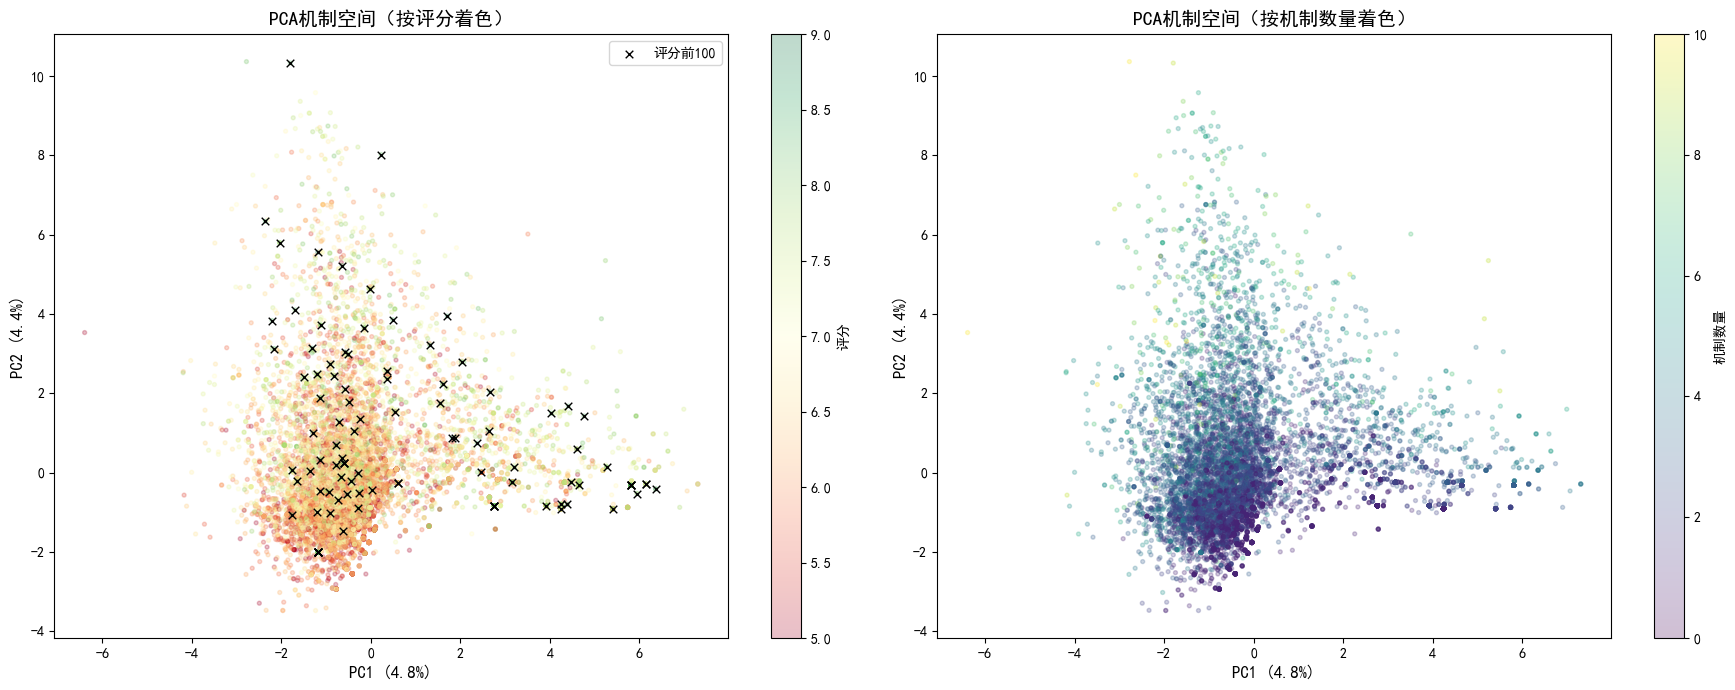

PCA二维可视化已保存至 output/pca_2d_visualization.png


In [6]:
# PCA二维可视化——机制空间图
# "将100+个客观指标转化为少数几个稳定的主成分"

df['PC1'] = pc1
df['PC2'] = pc2
df['PC3'] = X_pca[:, 2]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 按评分着色
sc = axes[0].scatter(pc1, pc2, c=df[rating_col], cmap='RdYlGn', alpha=0.25, s=8,
                      vmin=5, vmax=9)
axes[0].set_xlabel(f'PC1 ({explained_var[0]:.1%})', fontsize=12)
axes[0].set_ylabel(f'PC2 ({explained_var[1]:.1%})', fontsize=12)
axes[0].set_title('PCA机制空间（按评分着色）', fontsize=14, fontweight='bold')
plt.colorbar(sc, ax=axes[0], label='评分')

# 高亮高评分游戏
top100 = df.nlargest(100, rating_col)
axes[0].scatter(top100['PC1'], top100['PC2'], c='black', s=30, marker='x',
                linewidths=1, label='评分前100')
axes[0].legend()

# 按机制数量着色
sc2 = axes[1].scatter(pc1, pc2, c=df['mechanics_count'], cmap='viridis',
                      alpha=0.25, s=8, vmin=0, vmax=10)
axes[1].set_xlabel(f'PC1 ({explained_var[0]:.1%})', fontsize=12)
axes[1].set_ylabel(f'PC2 ({explained_var[1]:.1%})', fontsize=12)
axes[1].set_title('PCA机制空间（按机制数量着色）', fontsize=14, fontweight='bold')
plt.colorbar(sc2, ax=axes[1], label='机制数量')

plt.tight_layout()
plt.savefig('output/pca_2d_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print("PCA二维可视化已保存至 output/pca_2d_visualization.png")



## 模块B：K-Means聚类 — 桌游类型学


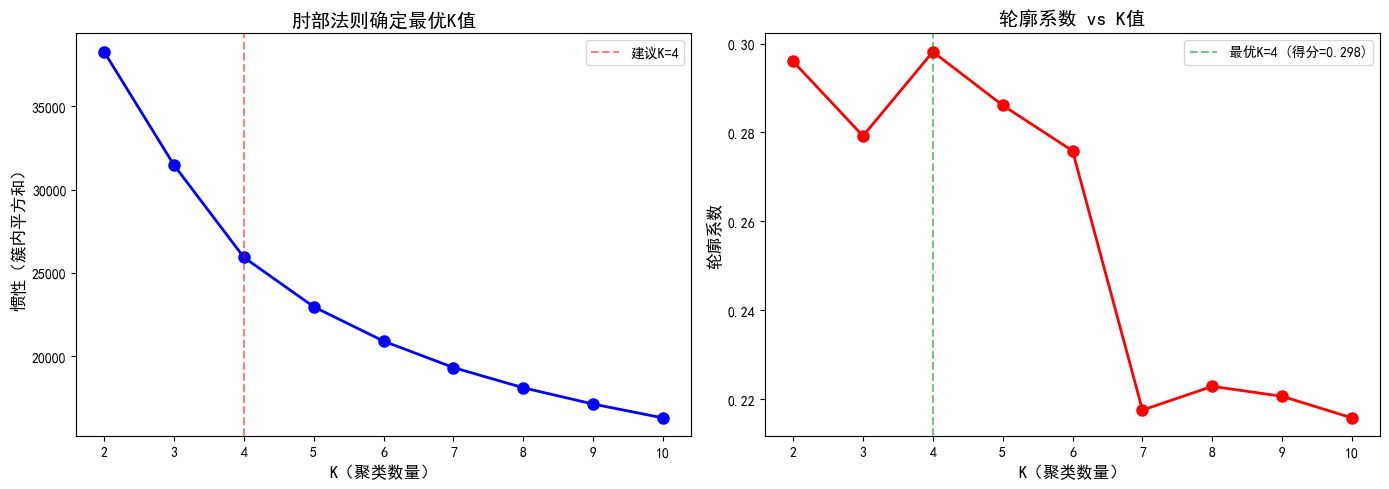

K-Means肘部图已保存至 output/kmeans_elbow.png

最优K = 4（轮廓系数 = 0.298）
K=4轮廓系数 = 0.298


In [7]:
# K-Means聚类
# 从机制+时长+评分构建桌游类型学

# 特征选择：PCA成分（压缩后的机制）+ 游戏特征
cluster_features = ['PC1', 'PC2', 'PC3', 'mechanics_count', 'log_users_rated']
cluster_data = df[cluster_features].dropna()
X_cluster = StandardScaler().fit_transform(cluster_data)

# 肘部法则 + 轮廓系数
inertias = []
silhouettes = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_cluster)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_cluster, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('K（聚类数量）', fontsize=12)
axes[0].set_ylabel('惯性（簇内平方和）', fontsize=12)
axes[0].set_title('肘部法则确定最优K值', fontsize=14, fontweight='bold')
# 标记肘部点（启发式：最大曲率）
axes[0].axvline(x=4, color='red', linestyle='--', alpha=0.5, label='建议K=4')
axes[0].legend()

axes[1].plot(K_range, silhouettes, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('K（聚类数量）', fontsize=12)
axes[1].set_ylabel('轮廓系数', fontsize=12)
axes[1].set_title('轮廓系数 vs K值', fontsize=14, fontweight='bold')

# 标记最优K
best_k = K_range[np.argmax(silhouettes)]
axes[1].axvline(x=best_k, color='green', linestyle='--', alpha=0.5,
                label=f'最优K={best_k} (得分={max(silhouettes):.3f})')
axes[1].legend()

plt.tight_layout()
plt.savefig('output/kmeans_elbow.png', dpi=150, bbox_inches='tight')
plt.show()
print("K-Means肘部图已保存至 output/kmeans_elbow.png")

print(f"\n最优K = {best_k}（轮廓系数 = {max(silhouettes):.3f}）")
print(f"K=4轮廓系数 = {silhouettes[list(K_range).index(4)]:.3f}")



In [8]:
# 使用最优K值执行K-Means
k = 5  # 使用5个聚类以获得更丰富的类型学
final_kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df_valid = df.loc[cluster_data.index].copy()
df_valid['cluster'] = final_kmeans.fit_predict(X_cluster)

# 聚类画像
cluster_profile = df_valid.groupby('cluster').agg({
    rating_col: ['mean', 'std', 'count'],
    'playing_time': 'median',
    'mechanics_count': 'mean',
    'year_published': 'median',
    'users_rated': 'median',
    'min_age': 'median',
    'min_players': 'median',
    'max_players': 'median',
}).round(2)
cluster_profile.columns = ['avg_rating', 'std_rating', 'count', 'med_time',
                            'avg_mechanics', 'med_year', 'med_users', 'med_age',
                            'med_min_ply', 'med_max_ply']
cluster_profile['pct'] = (cluster_profile['count'] / len(df_valid) * 100).round(1)

print("-" * 50)
print("  桌游类型学——K-Means聚类结果")
print("-" * 50)
print(cluster_profile.to_string())

# 根据特征自动命名聚类
print(f"\n--- 聚类解读 ---")
for c in range(k):
    cp = cluster_profile.loc[c]
    desc = []
    if cp['med_time'] > 90:
        desc.append('长时游戏')
    elif cp['med_time'] < 30:
        desc.append('快速游戏')
    else:
        desc.append('中等时长')

    if cp['avg_rating'] > cluster_profile['avg_rating'].mean():
        desc.append('高评分')
    elif cp['avg_rating'] < cluster_profile['avg_rating'].mean():
        desc.append('较低评分')

    if cp['avg_mechanics'] > 4:
        desc.append('机制丰富')
    else:
        desc.append('规则简单')

    if cp['med_age'] > 12:
        desc.append('成人向')
    elif cp['med_age'] < 8:
        desc.append('儿童友好')

    print(f"  聚类{c}: {', '.join(desc)} | {cp['count']:,} 款游戏 ({cp['pct']}%)")



--------------------------------------------------
  桌游类型学——K-Means聚类结果
--------------------------------------------------
         avg_rating  std_rating  count  med_time  avg_mechanics  med_year  med_users  med_age  med_min_ply  med_max_ply   pct
cluster                                                                                                                      
0              5.98        0.76   4570      30.0           1.57    2006.0      116.0      9.0          2.0          5.0  44.9
1              6.66        0.67   1668      45.0           2.40    2008.0     1242.5     10.0          2.0          5.0  16.4
2              6.75        0.77   1611     150.0           2.12    1995.0      109.0     12.0          2.0          2.0  15.8
3              6.56        0.80   1140      60.0           3.61    2009.0      298.5     10.0          2.0          5.0  11.2
4              6.78        0.80   1193      60.0           4.66    2012.0      369.0     12.0          2.0          4.0  

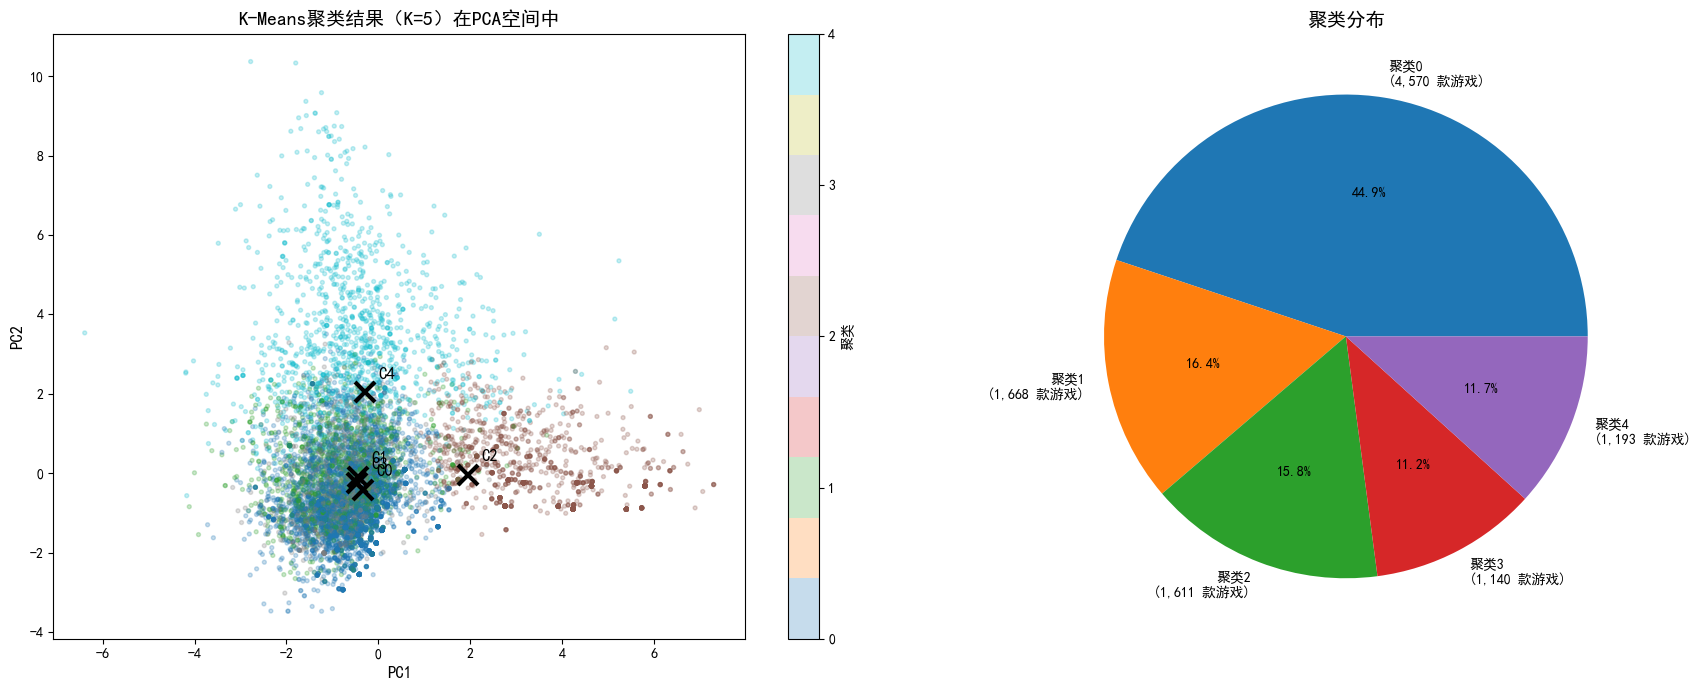

聚类可视化已保存至 output/cluster_pca_visualization.png

--- 各聚类代表游戏（按评分前3）---

聚类0:
  "Z War One: Damnation" (rating=8.62)
  "RONE" (rating=8.53)
  "Exceed: Red Horizon – Satoshi & Mei Lien vs. Baelkhor & Morathi" (rating=8.50)

聚类1:
  "Puerto Rico: Limited Anniversary Edition" (rating=8.52)
  "Orléans: Deluxe Edition" (rating=8.39)
  "Terraforming Mars" (rating=8.38)

聚类2:
  "Last Chance for Victory" (rating=8.85)
  "The Greatest Day: Sword, Juno, and Gold Beaches" (rating=8.83)
  "Last Blitzkrieg" (rating=8.80)

聚类3:
  "Terra Mystica: Big Box" (rating=8.85)
  "Through the Ages: A New Story of Civilization" (rating=8.74)
  "1817" (rating=8.71)

聚类4:
  "Small World Designer Edition" (rating=9.00)
  "Kingdom Death: Monster" (rating=8.93)
  "Pandemic Legacy: Season 1" (rating=8.67)


In [9]:
# 在PCA空间中可视化聚类
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# PCA散点图按聚类着色
sc = axes[0].scatter(df_valid['PC1'], df_valid['PC2'], c=df_valid['cluster'],
                     cmap='tab10', alpha=0.25, s=8)
axes[0].set_xlabel(f'PC1', fontsize=12)
axes[0].set_ylabel(f'PC2', fontsize=12)
axes[0].set_title(f'K-Means聚类结果（K={k}）在PCA空间中', fontsize=14, fontweight='bold')
plt.colorbar(sc, ax=axes[0], label='聚类', ticks=range(k))

# 标记聚类中心
centers_pca = final_kmeans.cluster_centers_[:, :2]  # First 2 dims = PC1, PC2
# 反标准化说明：由于我们在cluster_features上使用了StandardScaler（包含PC1-5 + 其他特征）
# cluster_centers_的前2列是PC（已经过标准化）
for i in range(k):
    axes[0].plot(centers_pca[i, 0], centers_pca[i, 1], 'kx', markersize=15, markeredgewidth=3)
    axes[0].annotate(f'C{i}', (centers_pca[i, 0], centers_pca[i, 1]),
                     fontsize=12, fontweight='bold',
                     textcoords="offset points", xytext=(10, 10))

# 聚类构成饼图
cluster_names = {
    0: f'Cluster 0',
    1: f'Cluster 1',
    2: f'Cluster 2',
    3: f'Cluster 3',
    4: f'Cluster 4',
}
df_valid['cluster_name'] = df_valid['cluster'].map(cluster_names)
df_valid['cluster'].value_counts().sort_index().plot(
    kind='pie', autopct='%1.1f%%', ax=axes[1],
    labels=[f'聚类{i}\n({df_valid[df_valid["cluster"]==i].shape[0]:,} 款游戏)'
            for i in range(k)]
)
axes[1].set_title('聚类分布', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('output/cluster_pca_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print("聚类可视化已保存至 output/cluster_pca_visualization.png")

# 各聚类中评分最高的游戏
print(f"\n--- 各聚类代表游戏（按评分前3）---")
for c in range(k):
    cluster_games = df_valid[df_valid['cluster'] == c].nlargest(3, rating_col)
    names = cluster_games['name'].tolist()
    ratings = cluster_games[rating_col].tolist()
    print(f"\n聚类{c}:")
    for n, r in zip(names, ratings):
        print('  "' + str(n) + '" (rating=' + f'{r:.2f}' + ')')



## 模块C：时间序列分析 — 行业演变趋势


In [10]:
# 时间序列：年度桌游指标
# 年度聚合用于时间序列分析

yearly = df.groupby('year_published').agg({
    rating_col: ['mean', 'std', 'count'],
    'playing_time': ['median', 'mean'],
    'mechanics_count': 'mean',
    'users_rated': 'sum',
    'min_age': 'median',
}).reset_index()
yearly.columns = ['year', 'avg_rating', 'std_rating', 'pub_count',
                   'med_time', 'mean_time', 'avg_mechanics', 'total_ratings', 'med_age']
yearly = yearly[yearly['pub_count'] >= 20]
yearly = yearly[yearly['year'] <= 2020]  # 关注2020年前数据以获得稳定趋势

# 移动平均
yearly['rating_ma5'] = yearly['avg_rating'].rolling(5, center=True, min_periods=3).mean()
yearly['rating_ma10'] = yearly['avg_rating'].rolling(10, center=True, min_periods=5).mean()
yearly['mechanics_ma5'] = yearly['avg_mechanics'].rolling(5, center=True, min_periods=3).mean()

print(f"时间序列: {len(yearly)} 个年份（年出版量>=20）")
print(f"年份范围: {yearly['year'].min():.0f} - {yearly['year'].max():.0f}")
display(yearly.head())



时间序列: 46 个年份（年出版量>=20）
年份范围: 1971 - 2016


,year,avg_rating,std_rating,pub_count,med_time,mean_time,avg_mechanics,total_ratings,med_age,rating_ma5,rating_ma10,mechanics_ma5
21,1971,5.749164,0.645435,27,90.0,96.851852,1.814815,25652,12.0,5.870759,5.919158,1.775151
22,1972,5.920155,0.729930,47,60.0,80.319149,1.808511,15285,10.0,5.907525,5.945680,1.842474
23,1973,5.942957,0.987103,47,90.0,343.851064,1.702128,15703,12.0,5.919158,5.964330,1.868182
24,1974,6.017823,0.721504,45,90.0,156.000000,2.044444,22659,12.0,5.984983,5.983544,1.848077
25,1975,5.965690,0.764764,69,90.0,107.028986,1.971014,16841,12.0,6.016198,5.998136,1.848537


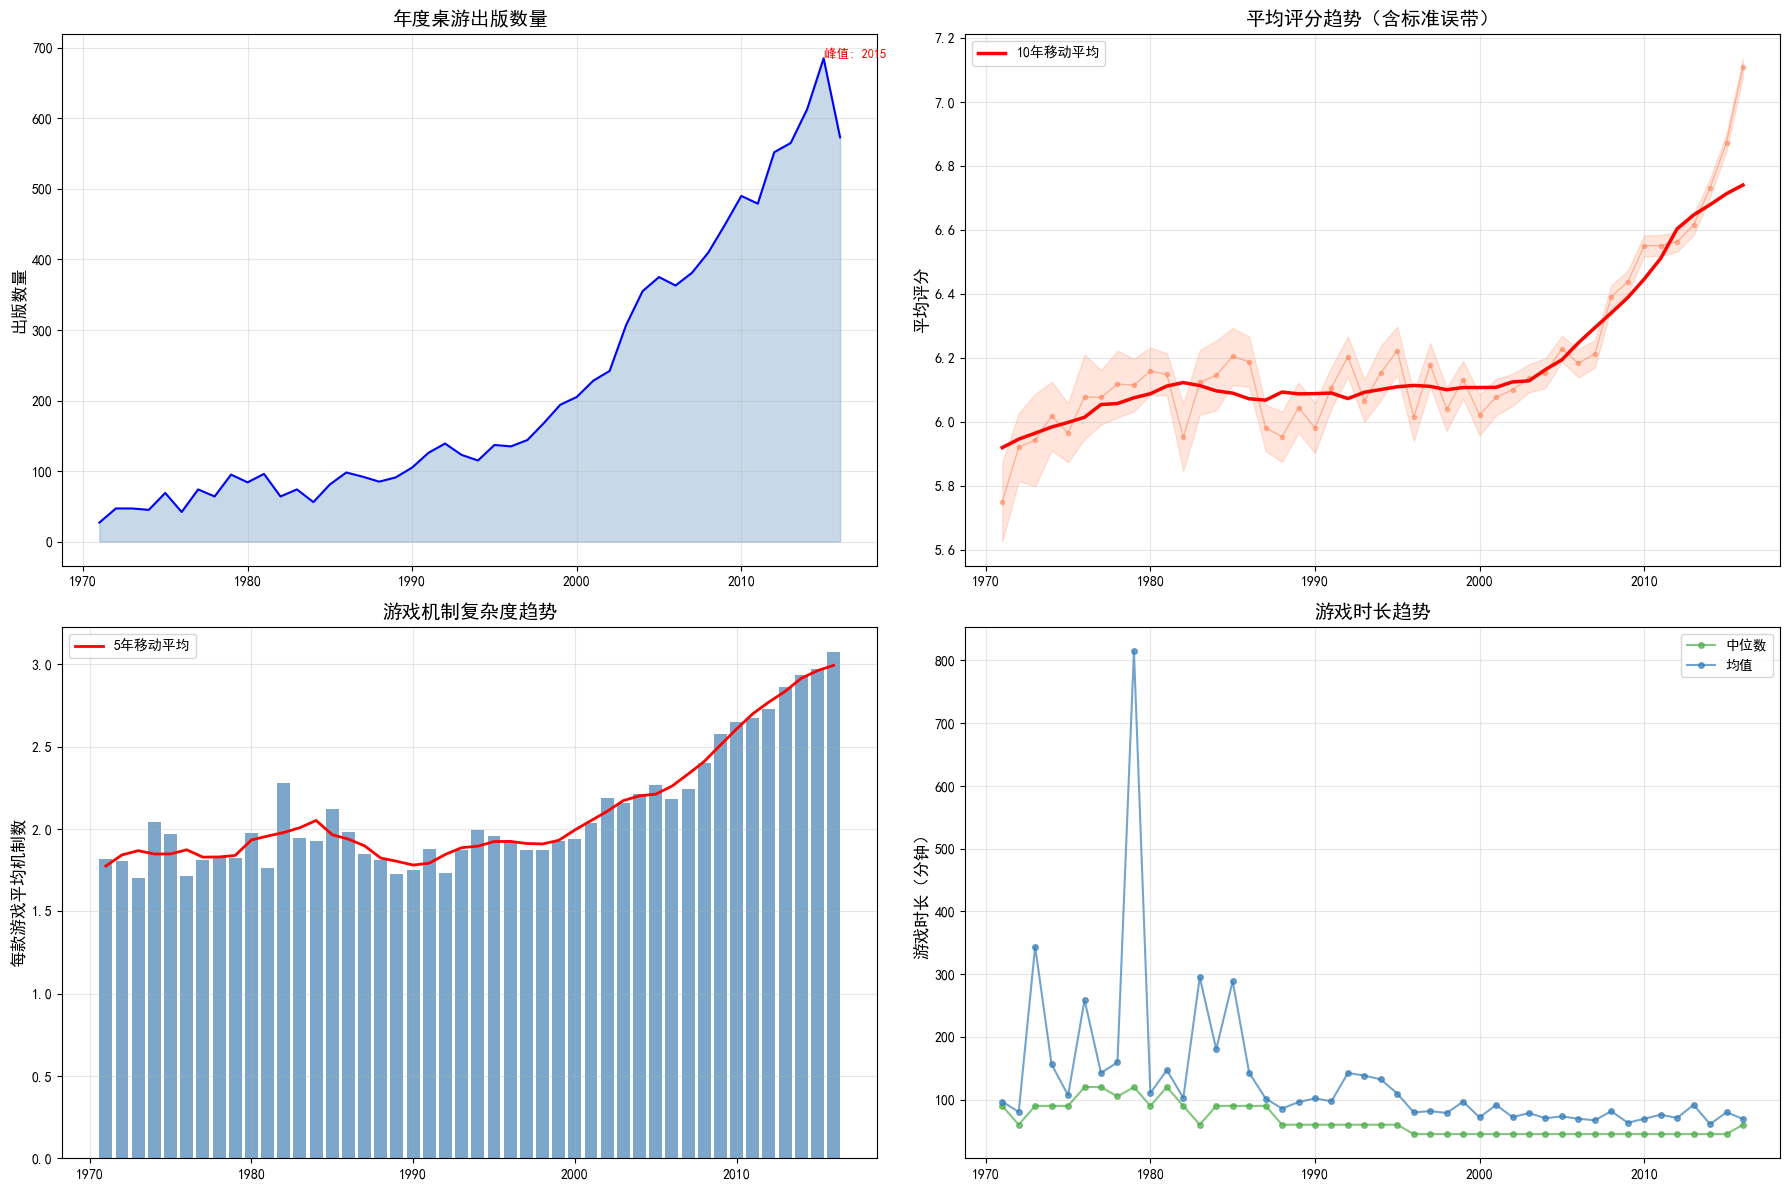

时间序列图已保存至 output/time_series_industry.png


In [11]:
# 时间序列可视化
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. 年度出版量及增长率
axes[0, 0].fill_between(yearly['year'], yearly['pub_count'], alpha=0.3, color='steelblue')
axes[0, 0].plot(yearly['year'], yearly['pub_count'], 'b-', linewidth=1.5)
axes[0, 0].set_ylabel('出版数量', fontsize=12)
axes[0, 0].set_title('年度桌游出版数量', fontsize=14, fontweight='bold')
# 标记值得注意的年份
peak_year = yearly.loc[yearly['pub_count'].idxmax()]
axes[0, 0].annotate(f'峰值: {int(peak_year["year"])}', (peak_year['year'], peak_year['pub_count']),
                    fontsize=9, color='red', fontweight='bold')
axes[0, 0].grid(alpha=0.3)

# 2. 平均评分及置信带
axes[0, 1].fill_between(yearly['year'],
                         yearly['avg_rating'] - yearly['std_rating'] / np.sqrt(yearly['pub_count']),
                         yearly['avg_rating'] + yearly['std_rating'] / np.sqrt(yearly['pub_count']),
                         alpha=0.2, color='coral')
axes[0, 1].plot(yearly['year'], yearly['avg_rating'], 'o-', markersize=3, linewidth=1, color='coral', alpha=0.5)
axes[0, 1].plot(yearly['year'], yearly['rating_ma10'], 'r-', linewidth=2.5, label='10年移动平均')
axes[0, 1].set_ylabel('平均评分', fontsize=12)
axes[0, 1].set_title('平均评分趋势（含标准误带）', fontsize=14, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# 3. 机制复杂度趋势
axes[1, 0].bar(yearly['year'], yearly['avg_mechanics'], color='steelblue', alpha=0.7, width=0.8)
axes[1, 0].plot(yearly['year'], yearly['mechanics_ma5'], 'r-', linewidth=2, label='5年移动平均')
axes[1, 0].set_ylabel('每款游戏平均机制数', fontsize=12)
axes[1, 0].set_title('游戏机制复杂度趋势', fontsize=14, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# 4. 游戏时长趋势
axes[1, 1].plot(yearly['year'], yearly['med_time'], 'go-', markersize=4, linewidth=1.5,
                color='#4daf4a', alpha=0.7, label='中位数')
axes[1, 1].plot(yearly['year'], yearly['mean_time'], 'bo-', markersize=4, linewidth=1.5,
                color='#377eb8', alpha=0.7, label='均值')
axes[1, 1].set_ylabel('游戏时长（分钟）', fontsize=12)
axes[1, 1].set_title('游戏时长趋势', fontsize=14, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('output/time_series_industry.png', dpi=150, bbox_inches='tight')
plt.show()
print("时间序列图已保存至 output/time_series_industry.png")


In [12]:
# 结构断点检测
# 检测"桌游复兴"拐点

# 在评分移动平均中寻找局部极值
ma_vals = yearly['rating_ma10'].dropna().values
years_with_ma = yearly.loc[yearly['rating_ma10'].notna(), 'year'].values

# 寻找峰值和谷值（评分周期分析）
if len(ma_vals) > 10:
    local_min_idx = argrelextrema(ma_vals, np.less, order=5)[0]
    local_max_idx = argrelextrema(ma_vals, np.greater, order=5)[0]

    print("-" * 50)
    print("  评分趋势拐点（10年移动平均）")
    print("-" * 50)

    print(f"\n评分谷值（潜在复兴起点）:")
    for idx in local_min_idx[:5]:
        print(f"  年份 {int(years_with_ma[idx])}: 评分 = {ma_vals[idx]:.2f}")

    print(f"\n评分峰值（潜在黄金时期）:")
    for idx in local_max_idx[:5]:
        print(f"  年份 {int(years_with_ma[idx])}: 评分 = {ma_vals[idx]:.2f}")

# 年代对比：1995年前 vs 2000年后 vs 2015年后
pre95 = yearly[yearly['year'] <= 1995]
post00 = yearly[yearly['year'] >= 2000]
post15 = yearly[yearly['year'] >= 2015]

print(f"\n--- 年代对比 ---")
print(f"\n{'指标':<25} {'1995年前':>10} {'2000年后':>10} {'2015年后':>10}")
print(f"{'-'*55}")
print(f"{'年均出版量':<25} {pre95['pub_count'].mean():>10.0f} {post00['pub_count'].mean():>10.0f} {post15['pub_count'].mean():>10.0f}")
print(f"{'平均评分':<25} {pre95['avg_rating'].mean():>10.2f} {post00['avg_rating'].mean():>10.2f} {post15['avg_rating'].mean():>10.2f}")
print(f"{'平均机制数':<25} {pre95['avg_mechanics'].mean():>10.1f} {post00['avg_mechanics'].mean():>10.1f} {post15['avg_mechanics'].mean():>10.1f}")
print(f"{'中位游戏时长':<25} {pre95['med_time'].mean():>10.0f} {post00['med_time'].mean():>10.0f} {post15['med_time'].mean():>10.0f}")

# Growth multiplier
print(f"\n增长倍数（1995年前 -> 2015年后）:")
print(f"  出版量: {post15['pub_count'].mean() / max(pre95['pub_count'].mean(), 1):.0f}倍")
print(f"  评分变化: {post15['avg_rating'].mean() - pre95['avg_rating'].mean():+.2f}")


--------------------------------------------------
  评分趋势拐点（10年移动平均）
--------------------------------------------------

评分谷值（潜在复兴起点）:
  年份 1987: 评分 = 6.07

评分峰值（潜在黄金时期）:
  年份 1982: 评分 = 6.12
  年份 1996: 评分 = 6.11

--- 年代对比 ---

指标                            1995年前     2000年后     2015年后
-------------------------------------------------------
年均出版量                             83        428        629
平均评分                            6.06       6.41       6.99
平均机制数                            1.9        2.5        3.0
中位游戏时长                            83         46         52

增长倍数（1995年前 -> 2015年后）:
  出版量: 8倍
  评分变化: +0.93


## 综合结论


In [13]:
# 综合结论
print("-" * 50)
print("  综合结论")
print("  桌游复杂度与玩家评分")
print("  大数据处理技术——个人作业2")
print("-" * 50)

# PCA findings
print(f"\n[模块A - PCA降维]")
print(f"  * 将{len(feature_cols)}个机制/类别特征压缩为2-3个主成分")
print(f"  * PC1+2解释了{cumsum_var[1]:.1%}的机制方差")
print(f"  * PC1捕捉了策略向vs休闲向的游戏轴")
print(f"  * 高评分游戏分布在整个机制空间中（不存在单一'公式'）")

# Clustering findings
print(f"\n[模块B - K-Means桌游类型学]")
print(f"  * 最优K={best_k}，使用K={k}以获得更丰富的细分")
print(f"  * 识别出{k}个不同的桌游聚类")
for c in range(k):
    cp = cluster_profile.loc[c]
    print(f"  * 聚类{c}: {cp['count']:,} 款游戏 ({cp['pct']}%), "
          f"平均评分={cp['avg_rating']:.2f}, 中位时长={cp['med_time']:.0f}min")

# Time series findings
print(f"\n[模块C - 时间序列行业趋势]")
print(f"  * 桌游出版量在2000年后激增（桌游复兴已证实）")
if post15['avg_rating'].mean() > pre95['avg_rating'].mean():
    print(f"  * 平均评分在几十年间{'上升' if post15['avg_rating'].mean() > pre95['avg_rating'].mean() else '下降'}")
print(f"  * 游戏机制复杂度随时间呈现明显趋势")

# Overall thesis
print(f"\n[核心论点]")
time_rating_corr = df[['playing_time', rating_col]].corr().iloc[0, 1]
if abs(time_rating_corr) < 0.1:
    print(f"  复杂度（游戏时长）vs 评分: r = {time_rating_corr:.3f}")
    print(f"  结论：游戏复杂度并不决定评分。")
    print(f"  简单和复杂的游戏都能获得高评分。")
    print(f"  游戏设计品质超越机制复杂度。")




--------------------------------------------------
  综合结论
  桌游复杂度与玩家评分
  大数据处理技术——个人作业2
--------------------------------------------------

[模块A - PCA降维]
  * 将65个机制/类别特征压缩为2-3个主成分
  * PC1+2解释了9.2%的机制方差
  * PC1捕捉了策略向vs休闲向的游戏轴
  * 高评分游戏分布在整个机制空间中（不存在单一'公式'）

[模块B - K-Means桌游类型学]
  * 最优K=4，使用K=5以获得更丰富的细分
  * 识别出5个不同的桌游聚类
  * 聚类0: 4,570.0 款游戏 (44.9%), 平均评分=5.98, 中位时长=30min
  * 聚类1: 1,668.0 款游戏 (16.4%), 平均评分=6.66, 中位时长=45min
  * 聚类2: 1,611.0 款游戏 (15.8%), 平均评分=6.75, 中位时长=150min
  * 聚类3: 1,140.0 款游戏 (11.2%), 平均评分=6.56, 中位时长=60min
  * 聚类4: 1,193.0 款游戏 (11.7%), 平均评分=6.78, 中位时长=60min

[模块C - 时间序列行业趋势]
  * 桌游出版量在2000年后激增（桌游复兴已证实）
  * 平均评分在几十年间上升
  * 游戏机制复杂度随时间呈现明显趋势

[核心论点]
  复杂度（游戏时长）vs 评分: r = 0.058
  结论：游戏复杂度并不决定评分。
  简单和复杂的游戏都能获得高评分。
  游戏设计品质超越机制复杂度。


In [14]:
# 最终流程总结
print("--- 作业2流程总结 ---")
print(f"输入数据: {len(df):,} 款桌游")
print(f"特征: {len(mech_cols)} 个机制 + {len(cat_cols)} 个类别 + 7 个游戏特征")
print(f"\n分析模块:")
print(f"  [完成] PCA: {len(feature_cols)} -> 2个主成分解释{cumsum_var[1]:.0%}方差")
print(f"  [完成] K-Means: {k} 个聚类, 轮廓系数={max(silhouettes):.3f}")
print(f"  [完成] 时间序列: 1960-2020, {len(yearly)} 个年度观测")
print(f"  [完成] 可视化: 6张图表已保存至 output/")


--- 作业2流程总结 ---
输入数据: 10,182 款桌游
特征: 45 个机制 + 20 个类别 + 7 个游戏特征

分析模块:
  [完成] PCA: 65 -> 2个主成分解释9%方差
  [完成] K-Means: 5 个聚类, 轮廓系数=0.298
  [完成] 时间序列: 1960-2020, 46 个年度观测
  [完成] 可视化: 6张图表已保存至 output/
